#Feature Extraction
This notebook demonstrates feature extraction steps for NLP using a preprocessed Amazon Fine Food Reviews dataset.

**Objective**: Convert cleaned review text into numerical features using Bag-of-Words, n-grams, and TF-IDF for downstream modeling (sentiment classification).


## Import Libraries

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## Load Data

We load the preprocessed dataset that contains the cleaned review text.
This data will be used for Bag-of-Words, n-grams, and TF-IDF feature extraction.

In [ ]:
# Load Preprocessed Dataset
df = pd.read_csv("/content/preprocessed_reviews1.csv")

print(" Preprocessed dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

# Verify that 'Text' column is clean
print("\nSample cleaned review:")
print(df['CleanedText'].iloc[0][:500])  # Print first 500 char

 Preprocessed dataset loaded successfully.
Shape: (365331, 11)

Sample cleaned review:
witty little book makes son laugh loud recite car driving along always sing refrain learned whales india drooping roses love new words book introduces silliness classic book willing bet son still able recite memory college


## Bag of Words (BoW)

We convert text into a matrix of word counts using CountVectorizer.
It helps us understand how often each word appears in the dataset.

In [ ]:
# Focus on the CleanedText column
preprocessed_reviews = df['CleanedText'].astype(str).values

# Initialize CountVectorizer
count_vect = CountVectorizer(max_features=50000)

# Fit the model
count_vect.fit(preprocessed_reviews)

# Transform the text data
final_counts = count_vect.transform(preprocessed_reviews)

# Display details
print("The type of CountVectorizer output:", type(final_counts))
print("The shape of our text BoW vectorizer:", final_counts.shape)
print("The number of unique words:", final_counts.shape[1])


The type of CountVectorizer output: <class 'scipy.sparse._csr.csr_matrix'>
The shape of our text BoW vectorizer: (365331, 50000)
The number of unique words: 50000


In [ ]:
features = count_vect.get_feature_names_out()
# Shuffle and print 10 random feature names
np.random.shuffle(features)
print("Some random feature names:", features[:10])
print("=" * 60)


Some random feature names: ['guajilio' 'tumor' 'solely' 'rubust' 'delicicious' 'mostly' 'tasteof'
 'cattle' 'outclasses' 'heretics']


In [ ]:
word_freq = np.array(final_counts.sum(axis=0)).flatten()
top_cols = word_freq.argsort()[-10:]  # top 10 most frequent


In [ ]:
sample = final_counts[:5][:, top_cols].toarray()
pd.DataFrame(sample, columns=count_vect.get_feature_names_out()[top_cols])


,coffee,flavor,would,product,taste,one,great,good,like,not
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0
3,0,0,0,0,0,0,1,1,2,1
4,0,0,0,0,0,0,0,0,0,0


The table above shows a small part of our Bag-of-Words matrix.  
We selected:
- 5 reviews (rows)
- 10 of the most frequent words (columns)

Each number represents **how many times that word appears in that review.**

#### Example: Row 3 (4th review in this sample)
This means:
- **"good"** appears 1 time in this review  
- **"like"** appears 2 times  
- **"not"** appears 1 time  
- The other words (**coffee, flavor, product, taste, one, great**) do not appear in this review (0)

####  Why most values are zero
In text data, each review only contains a small subset of all the possible words in the corpus.  
That means most entries in the matrix are zero — this is called a **sparse matrix**.



## Bi-Grams and n-grams

Here we capture both single words and word pairs to retain context.
N-grams help extract more meaningful patterns from text compared to BoW.

In [ ]:
preprocessed_reviews = df['CleanedText'].astype(str).values

# Initialize CountVectorizer with n-gram range
ngram_vectorizer = CountVectorizer(ngram_range=(1, 2) ,min_df=10, max_features=5000)  # (1,2) = unigrams + bigrams

# Fit the vectorizer to learn vocabulary
ngram_vectorizer.fit(preprocessed_reviews)

# Show sample feature names
print("Some n-gram feature names:", ngram_vectorizer.get_feature_names_out()[:15])
print("=" * 70)

# Transform the text data
final_ngram_counts = ngram_vectorizer.transform(preprocessed_reviews)

# Show matrix details
print("The type of N-Gram Vectorizer output:", type(final_ngram_counts))
print("The shape of our text N-Gram vectorizer:", final_ngram_counts.shape)
print("The number of unique n-grams:", final_ngram_counts.shape[1])

Some n-gram feature names: ['ability' 'able' 'able buy' 'able find' 'able get' 'able order'
 'absolute' 'absolute favorite' 'absolutely' 'absolutely delicious'
 'absolutely love' 'absolutely loved' 'absolutely loves' 'absolutely no'
 'absorb']
The type of N-Gram Vectorizer output: <class 'scipy.sparse._csr.csr_matrix'>
The shape of our text N-Gram vectorizer: (365331, 5000)
The number of unique n-grams: 5000


#TF-IDF

TF-IDF gives higher weight to important words and lower weight to common ones.
This produces more informative features for machine learning models.

In [ ]:
# Using CleanedText column from preprocessed CSV
tfidf_vectorizer = TfidfVectorizer(max_features=5000)  # limit vocab size for efficiency

# Fit the vectorizer
tfidf_vectorizer.fit(df['CleanedText'].astype(str).values)

# Sample feature names
print("Some TF-IDF feature names:", tfidf_vectorizer.get_feature_names_out()[:15])
print("=" * 70)

# Transform data
final_tfidf = tfidf_vectorizer.transform(df['CleanedText'].astype(str).values)

# Print details
print("The type of TF-IDF Vectorizer output:", type(final_tfidf))
print("The shape of our TF-IDF vectorizer:", final_tfidf.shape)
print("The number of unique words/features:", final_tfidf.shape[1])

Some TF-IDF feature names: ['ability' 'able' 'absolute' 'absolutely' 'absorb' 'absorbed' 'acai'
 'accept' 'acceptable' 'access' 'accident' 'accidentally' 'according'
 'account' 'accurate']
The type of TF-IDF Vectorizer output: <class 'scipy.sparse._csr.csr_matrix'>
The shape of our TF-IDF vectorizer: (365331, 5000)
The number of unique words/features: 5000


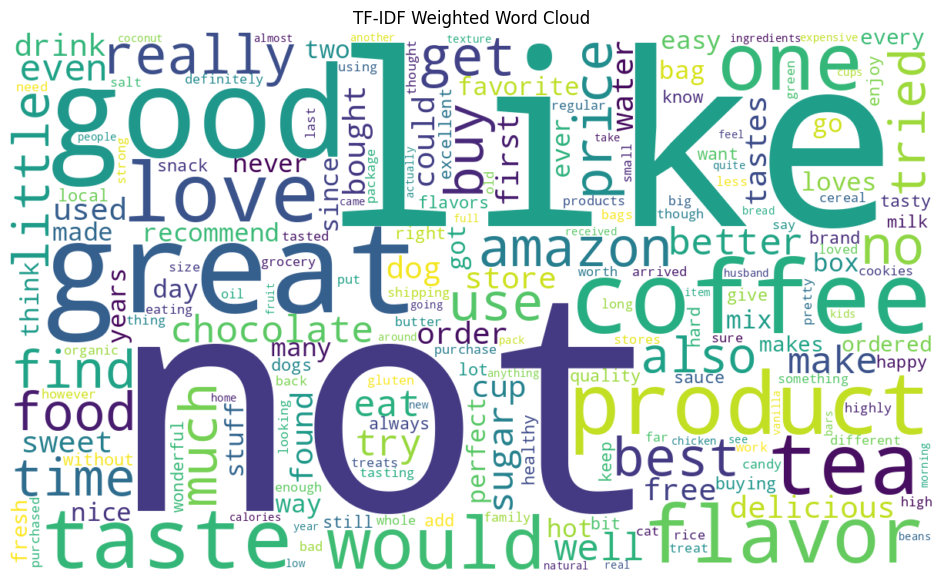

In [ ]:

import matplotlib.pyplot as plt
import numpy as np

# Sum TF-IDF scores across all documents
tfidf_scores = np.asarray(final_tfidf.sum(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()

# Map words to scores
word_scores = dict(zip(feature_names, tfidf_scores))

# Generate the word cloud
wc = WordCloud(width=1200, height=700, background_color="white")
wc.generate_from_frequencies(word_scores)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("TF-IDF Weighted Word Cloud")
plt.show()


#TF-IDF with bigrams

We extend TF-IDF to include bigrams for richer contextual understanding.
This representation is useful for capturing phrase-level importance.

In [ ]:
# TF-IDF with unigrams + bigrams
tfidf_bigram_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=8000)

# Fit on preprocessed CleanedText column
tfidf_bigram_vectorizer.fit(df['CleanedText'].astype(str).values)

# Show some feature names
print("Some TF-IDF bigram feature names:", tfidf_bigram_vectorizer.get_feature_names_out()[:15])
print("=" * 70)

# Transform the text into TF-IDF features
final_tfidf_bigram = tfidf_bigram_vectorizer.transform(df['CleanedText'].astype(str).values)

Some TF-IDF bigram feature names: ['ability' 'able' 'able buy' 'able eat' 'able find' 'able get' 'able make'
 'able order' 'able purchase' 'able use' 'absolute' 'absolute best'
 'absolute favorite' 'absolutely' 'absolutely best']


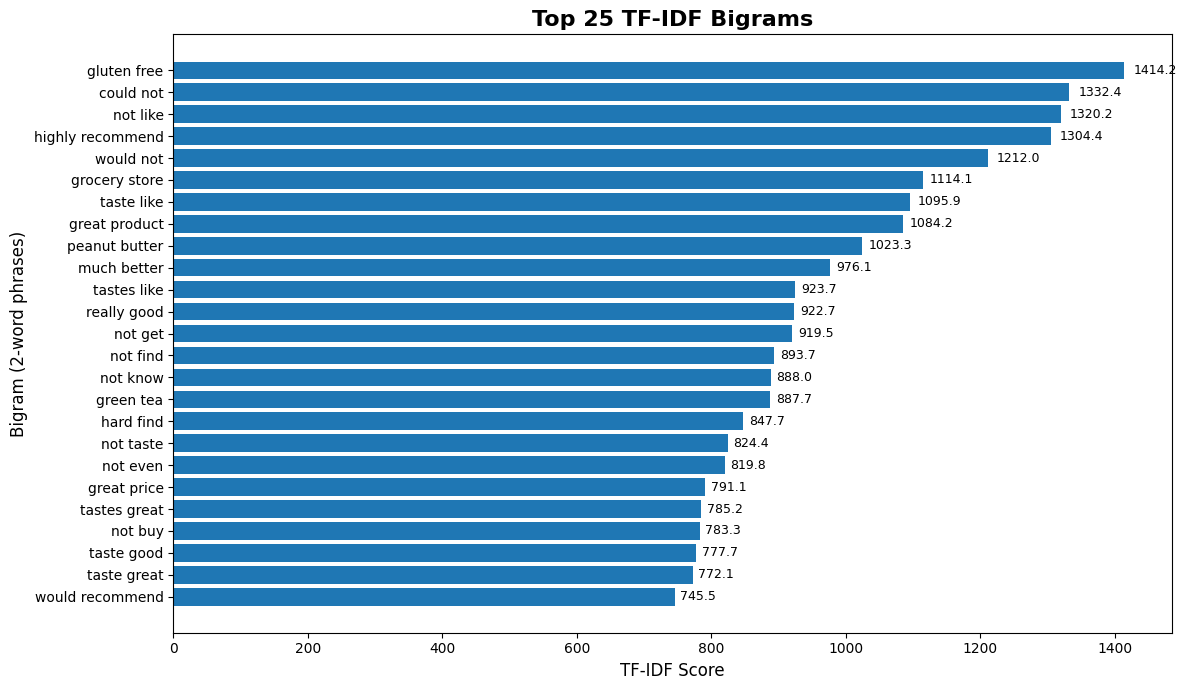

In [ ]:
# Sum TF-IDF weights across all documents
bigram_scores = np.asarray(final_tfidf_bigram.sum(axis=0)).flatten()
bigram_features = tfidf_bigram_vectorizer.get_feature_names_out()

#Create DF
bigram_df = pd.DataFrame({'ngram': bigram_features, 'score': bigram_scores})

#Keep ONLY bigrams (exactly two words)
bigram_df = bigram_df[bigram_df['ngram'].str.contains(r'^\w+\s\w+$')]

# Sort top 25 bigrams
top_bigrams = bigram_df.sort_values(by="score", ascending=False).head(25)

# Plot
plt.figure(figsize=(12, 7))
bars = plt.barh(top_bigrams['ngram'], top_bigrams['score'])
plt.gca().invert_yaxis()

plt.title("Top 25 TF-IDF Bigrams", fontsize=16, weight='bold')
plt.xlabel("TF-IDF Score", fontsize=12)
plt.ylabel("Bigram (2-word phrases)", fontsize=12)

# Add TF-IDF values on bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01 * width, bar.get_y() + bar.get_height()/2,
             f"{width:.1f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()


The bigram TF-IDF visualization highlights the most informative two-word phrases in the reviews. It captures clearer context than single words, surfacing key sentiment patterns (e.g., “highly recommend,” “not like”) and product attributes (e.g., “gluten free,” “green tea”). This helps reveal common preferences and complaints more accurately.

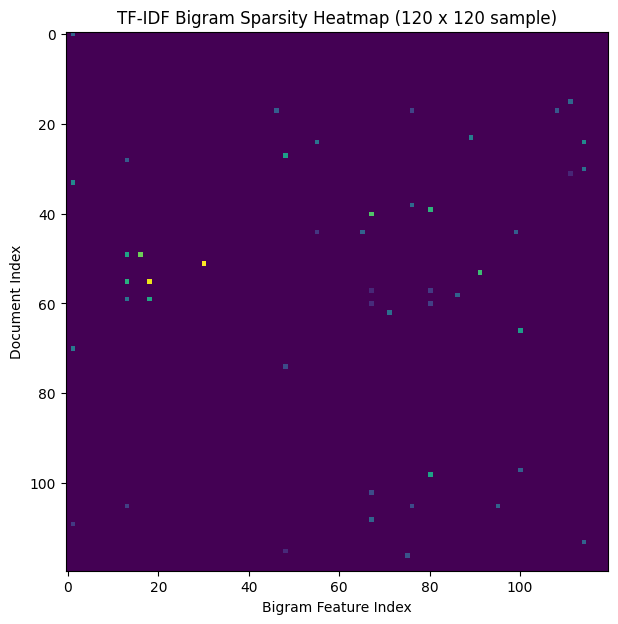

In [ ]:
# Take a smaller slice for clarity (visualizing full 8k features is too dense)
sample_bigram = final_tfidf_bigram[:120, :120].toarray()

plt.figure(figsize=(7, 7))
plt.imshow(sample_bigram, aspect='auto')
plt.title("TF-IDF Bigram Sparsity Heatmap (120 x 120 sample)")
plt.xlabel("Bigram Feature Index")
plt.ylabel("Document Index")
plt.show()

The heatmap shows that only a few bigram phrases appear across documents, while most remain zero. This confirms the high sparsity of bigram TF-IDF features, making them efficient for downstream text classification.

## Summary
We extracted numerical features from cleaned review text using Bag-of-Words, n-grams, and TF-IDF.
These sparse feature matrices (BoW, n-grams, TF-IDF) are ready for downstream tasks like sentiment classification.